<a href="https://colab.research.google.com/github/ardhiansyahprimadikaadi/AI_Praktikum-1/blob/main/AI_Praktikum_Linear_Sederhana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum Analisis Code Regresi Linear Sederhana**
## Dataset : Harga Rumah
### Nama : Ardhiansyah Primadika Adi
### Kelas : H6C
### NIM : 09020624024


---



### Langkab 1 : Impor Library
Tahap awal adalah memanggil semua modul yang diperlukan untuk pengolahan data, perhitungan numerik, pemodelan, dan visualisasi.
*  pandas: Digunakan untuk mengonversi data mentah menjadi struktur tabel (DataFrame).
*  numpy: Dibutuhkan untuk operasi matematika, seperti menghitung akar kuadrat pada metrik RMSE.
*  matplotlib: Digunakan untuk menyajikan hasil dalam bentuk grafik.
*  sklearn: Library utama untuk algoritma machine learning (Regresi) dan metrik evaluasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

### Langkah 2 : Menyiapkan Dataset Baru
Di langkah ini, menyiapkan data buatan sendiri lalu dimasukkan ke DataFrame.
*   Variabel Luas Rumah menggunakan satuan meter persegi ($m^2$).
*   Variabel Harga Rumah menggunakan satuan juta rupiah.

In [2]:
# Data hubungan luas rumah dengan harga rumah
data = {
    'luas_rumah': [30, 45, 60, 70, 90, 100, 120, 150, 180, 200],
    'harga_rumah': [200, 310, 420, 500, 650, 720, 850, 1100, 1300, 1450]
}
df = pd.DataFrame(data)
print(df)

   luas_rumah  harga_rumah
0          30          200
1          45          310
2          60          420
3          70          500
4          90          650
5         100          720
6         120          850
7         150         1100
8         180         1300
9         200         1450


### Langkah 3: Menentukan Variabel X dan y
Memisahkan fitur independen (x) dan target dependen (y).

In [3]:
X = df[['luas_rumah']]
y = df['harga_rumah']

### Langkah 4: Pembagian Data
Membagi data untuk proses belajar dan pengujian.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Langkah 5: Inisialisasi dan Pelatihan Model
Pada tahap ini, model mempelajari pola data dimana nodel dibuat menggunakan objek LinearRegression() dan dilatih dengan fungsi .fit() untuk mencari pola hubungan linear antara luas dan harga.

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Langkah 6: Menampilkan Parameter Regresi
Mengeluarkan angka intercept ($a$) dan koefisien ($b$).

In [6]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b):", model.coef_[0])

Intercept (a): -19.15233415233422
Koefisien (b): 7.36977886977887


### Langkah 7: Prediksi Data Testing
Menguji hasil prediksi model terhadap data pengujian.

In [9]:
y_pred = model.predict(X_test)

print("Data Testing (m2):")
print(X_test)
print("Harga Asli (Juta):", y_test.values)
print("Harga Prediksi (Juta):", y_pred)

Data Testing (m2):
   luas_rumah
8         180
1          45
Harga Asli (Juta): [1300  310]
Harga Prediksi (Juta): [1307.40786241  312.48771499]


### Langkah 8: Evaluasi Metrik (MAE, MSE, RMSE)
Menghitung selisih kesalahan antara prediksi dengan data lapangan.

In [10]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 4.947788697788695
MSE: 30.532575656961686
RMSE: 5.525628982926893


### Langkah 9: Prediksi Data Baru
Memprediksi harga untuk rumah dengan luas yang tidak ada di dataset, misalnya luas 250 m2.

In [12]:
prediksi = model.predict([[250]])
print("Prediksi harga untuk luas rumah 250 m2:", prediksi[0], "juta rupiah")

Prediksi harga untuk luas rumah 250 m2: 1823.2923832923834 juta rupiah


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Langkah 10: Visualisasi Grafik
Menampilkan titik data asli dan garis hasil prediksi regresi.

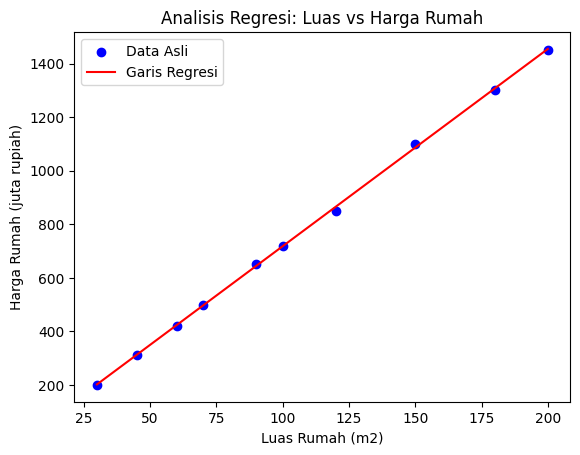

In [13]:
plt.scatter(X, y, color='blue', label="Data Asli")
plt.plot(X, model.predict(X), color='red', label="Garis Regresi")
plt.xlabel("Luas Rumah (m2)")
plt.ylabel("Harga Rumah (juta rupiah)")
plt.title("Analisis Regresi: Luas vs Harga Rumah")
plt.legend()
plt.show()

## **Analisis Hasil Berdasarkan Ouput**
### **Analisis Rgresi Parameter**
*   *Intercept (-19.15)*: Nilai negatif ini secara matematis berarti jika luas
rumah adalah 0, maka harganya -19 Juta. Dalam konteks ekonomi, ini sering terjadi pada model linear sederhana karena data Anda dimulai dari luas 30 $m^2$. Intercept di sini lebih berfungsi sebagai konstanta penyeimbang agar garis regresi tepat sasaran pada rentang data yang ada.
*   *Koefisien (7.36):* Nilai 7.36 menunjukkan bahwa setiap penambahan 1 m2 luas, harga rumah akan naik sebesar 7,36 Juta Rupiah. Ini memberikan gambaran yang jelas bagi penyedia properti mengenai harga per meter persegi bangunan dalam dataset ini.

### **Analisis Akurasi melalui Metrik Evaluasi**
Hasil perhitungan menunjukkan nilai MAE sebesar 4.94 dan RMSE sebesar 5.52. Dengan rentang harga rumah mencapai 1.450 juta rupiah, nilai deviasi sekitar 5,5 juta rupiah tergolong sangat kecil. Hal ini membuktikan bahwa tingkat presisi yang tinggi dalam melakukan estimasi harga.

### **Analisis Data Testing & Prediksi**
*  **Hasil Testing** : Pada luas 180 $m^2$, harga asli adalah 1300 Juta, sementara model memprediksi 1307 Juta. Selisihnya hanya sekitar 7 Juta Rupiah. Pada luas 45 $m^2$, harga asli 310 Juta dan prediksi 312 Juta. Konsistensi selisih yang kecil ini membuktikan model tidak mengalami overfitting atau underfitting.
*  **Hasil Prediksi** : Prediksi untuk luas 250 $m^2$ menghasilkan harga 1.823 Juta (1,8 Miliar Rupiah). Meskipun data asli hanya sampai 200 $m^2$, model mampu memberikan estimasi yang logis berdasarkan tren linear yang sudah terbentuk.


### **Analisis Scatterplot**
Melalui grafik scatter plot, terlihat bahwa titik-titik data aktual (biru) terletak sangat rapat mengikuti garis regresi (merah). Konsistensi sebaran data ini memvalidasi bahwa hubungan antara luas rumah dan harga properti bersifat linear secara signifikan.

### **Kesimpulan**
Model regresi linear sederhana ini terbukti sangat valid dan akurat dalam memetakan hubungan linear positif antara luas rumah dan harga properti. Keberhasilan model ini terlihat dari nilai koefisien sebesar 7,36 yang menunjukkan tren kenaikan harga yang stabil untuk setiap penambahan luas satu meter persegi, serta nilai RMSE yang sangat rendah (5,52) yang mengonfirmasi bahwa tingkat kesalahan prediksi sangat minimal dibandingkan dengan nilai aset rumah yang mencapai miliaran rupiah. Konsistensi selisih harga yang kecil pada data testing serta kedekatan visual antara titik data aktual dengan garis regresi pada scatterplot membuktikan bahwa model tidak mengalami overfitting dan memiliki kemampuan generalisasi yang andal untuk melakukan taksiran harga properti berdasarkan tren data yang telah terbentuk.




